In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
import os
path = os.getcwd() + '/ex1data1.txt'
data = pd.read_csv(path, header=None, names=['Population', 'Profit'])

       Population     Profit
count   97.000000  97.000000
mean     8.159800   5.839135
std      3.869884   5.510262
min      5.026900  -2.680700
25%      5.707700   1.986900
50%      6.589400   4.562300
75%      8.578100   7.046700
max     22.203000  24.147000
   Population   Profit
0      6.1101  17.5920
1      5.5277   9.1302
2      8.5186  13.6620
3      7.0032  11.8540
4      5.8598   6.8233


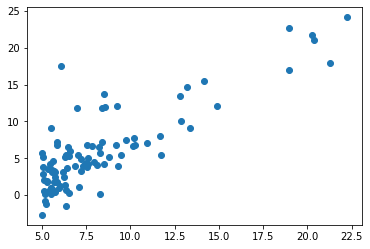

In [5]:
print(data.describe())
print(data.head())
x = data.values[:, 0]
y = data.values[:, 1]
plt.scatter(x,y)

In [6]:
X = np.stack([np.ones(x.shape, dtype=np.float32), x], axis=0)
y.shape = [1, y.shape[0]]
theta = np.zeros((X.shape[0], 1), dtype=np.float32)

5

In [7]:
def computeCost(X, y, theta):
    a=(theta.transpose()@X-y)**2
    return np.sum(a)/(2*len(y[0]))

computeCost(X,y,theta)

32.072733877455676

7

In [8]:
def simple_gradient(X, y, theta, alpha, it):
    cost=[computeCost(X,y,theta)]
    hTheta=theta
    for i in range(it):
        '''     hTheta[0]-=alpha*np.sum((hTheta.transpose()@X-y))/len(y[0])'''
        '''hTheta[0]-=alpha*(hTheta.transpose()@X-y)@X[0]/len(y[0])'''
        amount=len(y[0])
        hTheta-=alpha*((theta.transpose()@X-y)@X.transpose()/amount).transpose()
        cost.append(computeCost(X,y,hTheta))
        if cost[-1]>cost[-2]:
            break
        else:
            theta=hTheta
 
    return theta, np.array(cost)


8, 9

In [9]:
alpha = 0.01
it = 1000
theta,cost=simple_gradient(X, y, theta, alpha, it)
print(theta)

[[-3.2414012]
 [ 1.1272942]]


10

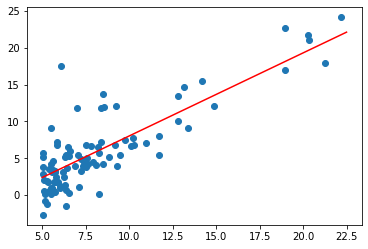

In [10]:
def vtheta(theta,x):
    return theta[0]+theta[1]*x
fig, ax = plt.subplots()
plt.scatter(x,y)
plt.plot([5,22.5],[vtheta(theta,5),vtheta(theta,22.5)],'r')


11

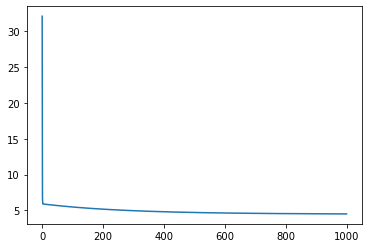

In [11]:
plt.plot(cost)

12

In [12]:
path = os.getcwd() + '/ex1data2.txt'
data2 = pd.read_csv(path, header=None, names=['Size', 'Bedrooms', 'Price'])
data2.head()

,Size,Bedrooms,Price
0,2104,3,399900
1,1600,3,329900
2,2400,3,369000
3,1416,2,232000
4,3000,4,539900


Feature Normalisation

In [13]:
s=np.array(data2["Size"])
mean=np.mean(s)
std=np.std(s)
normSize=(s-mean)/std
normPrice=np.array(data2["Price"])

'''Normalizacja ceny'''
'''s=np.array(data2["Price"])
mean=np.mean(s)
std=np.std(s)
normPrice=(s-mean)/std'''

x = data2.values[:, 1]
y = normPrice
z = normSize

In [14]:
X = np.stack([np.ones(x.shape, dtype=np.float32), x,z], axis=0)
'''Z = np.stack([np.ones(z.shape, dtype=np.float32), z], axis=0)'''
y.shape = [1, y.shape[0]]
theta = np.zeros((X.shape[0], 1), dtype=np.float32)
alpha = 0.01
it = 10000
theta,cost=simple_gradient(X, y, theta, alpha, it)
print(theta)

[[356052.9   ]
 [ -5061.2754]
 [107843.9   ]]


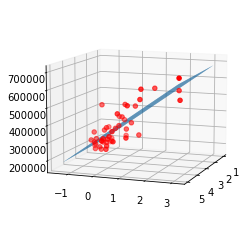

In [15]:
def vtheta(theta,x,z):
    return theta[0]+theta[1]*x+theta[1]*z
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.scatter(x, z,y, c='r')


Xs = np.arange(min(x), max(x), 0.25)
Zs = np.arange(min(z), max(z), 0.25)
Xs, Zs = np.meshgrid(Xs, Zs)
Ys = theta[0]+theta[1]*Xs+theta[2]*Zs
ax.plot_surface(Xs, Zs, Ys, vmin=Zs.min() * 2)
ax.view_init(elev=10., azim=20)

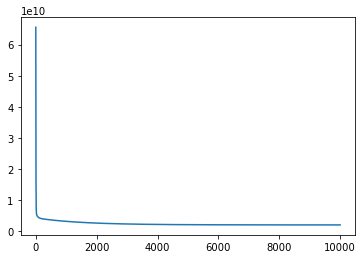

In [16]:
plt.plot(cost)

In [17]:
X = np.array([[1, 1], [1, 2], [2, 2], [2, 3]])
 # y = 1 * x_0 + 2 * x_1 + 3
y = np.dot(X, np.array([1, 2])) + 3
print(y)

[ 6  8  9 11]


In [19]:
import numpy as np
from sklearn import datasets, linear_model
from sklearn.model_selection import train_test_split
 
# Data import
import os
path = os.getcwd() + '/ex1data1.txt'
data = pd.read_csv(path, header=None, names=['Population', 'Profit'])
x = data.values[:, 0]
y = data.values[:, 1]
'''X = np.stack([np.ones(x.shape, dtype=np.float32), x], axis=0)
y.shape = [1, y.shape[0]]'''

# Normalization

 
# Split into train and test sets (70-30%)
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.30, random_state=42)
 
# Creating an object 
regr = linear_model.LinearRegression()
 
# Learning model on training data
regr.fit(X_train.reshape(-1, 1), Y_train.reshape(-1, 1))
# Predicting values using test data
Y_predicted = regr.predict(X_test.reshape(-1, 1))
 
# Regression coefficients (theta)
print('Coefficients: \n', regr.coef_,regr.intercept_)
 
#  Residual sum of squares error
error = np.mean((regr.predict(X_test.reshape(-1, 1)) - Y_test.reshape(-1, 1)) ** 2)
print("Residual sum of squares: {}".format(error))

Coefficients: 
 [[1.277562]] [-4.65290183]
Residual sum of squares: 11.267369947225895


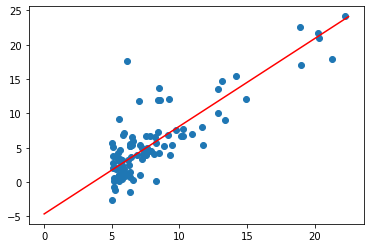

In [28]:
plt.scatter(x,y)
plt.plot([0,22.5],[regr.intercept_,22.5*regr.coef_+regr.intercept_],c='r')